In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
train = pd.read_csv('/kaggle/input/sharif-ml-1401-c6/assignment6-training-data.csv.csv')
train.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [5]:
test = pd.read_csv('/kaggle/input/sharif-ml-1401-c6/assignment6-test-data-sample_submission.csv.csv')
test.head()

,Sentiment,ID
0,2,1
1,0,2
2,1,3
3,2,4
4,3,5


In [7]:
combined = pd.concat([train,test])
combined.head()

,PhraseId,SentenceId,Phrase,Sentiment,ID
0,1.0,1.0,A series of escapades demonstrating the adage ...,1,NaN
1,2.0,1.0,A series of escapades demonstrating the adage ...,2,NaN
2,3.0,1.0,A series,2,NaN
3,4.0,1.0,A,2,NaN
4,5.0,1.0,series,2,NaN


In [6]:
combined.infer_objects()

,PhraseId,SentenceId,Phrase,Sentiment,ID
0,1.0,1.0,A series of escapades demonstrating the adage ...,1,NaN
1,2.0,1.0,A series of escapades demonstrating the adage ...,2,NaN
2,3.0,1.0,A series,2,NaN
3,4.0,1.0,A,2,NaN
4,5.0,1.0,series,2,NaN
...,...,...,...,...,...
1007,NaN,NaN,NaN,1,1008.0
1008,NaN,NaN,NaN,0,1009.0
1009,NaN,NaN,NaN,2,1010.0
1010,NaN,NaN,NaN,4,1011.0


In [9]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 156060 entries, 0 to 1011
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   PhraseId    155048 non-null  float64
 1   SentenceId  155048 non-null  float64
 2   Phrase      155048 non-null  object 
 3   Sentiment   156060 non-null  int64  
 4   ID          1012 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 7.1+ MB


In [11]:
combined.dtypes

PhraseId      float64
SentenceId    float64
Phrase         object
Sentiment       int64
ID            float64
dtype: object

In [13]:
combined.isnull().sum()/len(combined)*100

PhraseId       0.648469
SentenceId     0.648469
Phrase         0.648469
Sentiment      0.000000
ID            99.351531
dtype: float64

In [14]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
PhraseId,155048.0,77524.500000,44758.646606,1.0,38762.75,77524.5,116286.25,155048.0
SentenceId,155048.0,4050.787575,2485.057572,1.0,1849.00,3987.0,6199.00,8485.0
Sentiment,156060.0,2.063751,0.898172,0.0,2.00,2.0,3.00,4.0
ID,1012.0,506.500000,292.283538,1.0,253.75,506.5,759.25,1012.0


In [16]:
combined.shape

(156060, 5)

<AxesSubplot: >

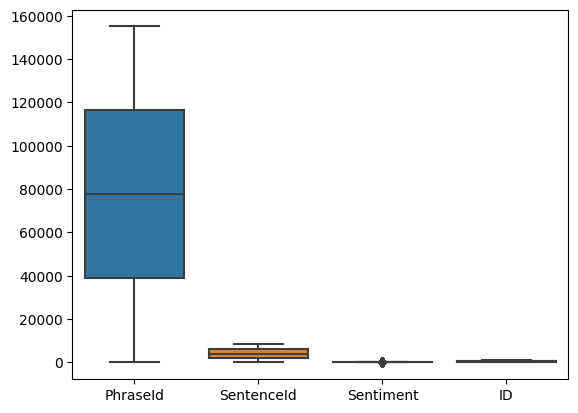

In [17]:
sns.boxplot(combined)

<AxesSubplot: >

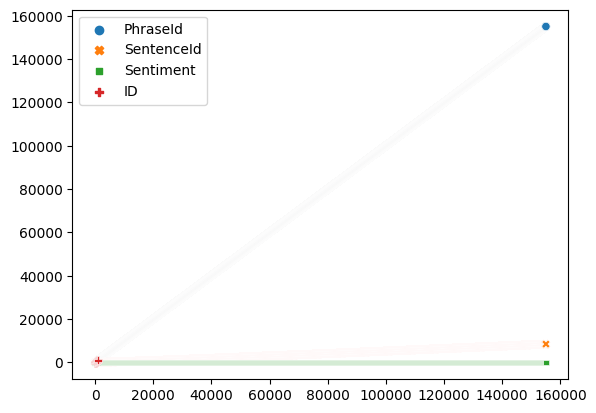

In [18]:
sns.scatterplot(combined)

In [7]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

PhraseId      77523.5
SentenceId     4350.0
Sentiment         1.0
ID              505.5
dtype: float64


/tmp/ipykernel_35/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_35/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_35/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [8]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [ ]:
combined_new = combined[~(combined>UL)|(combined<LL).any(axis=1)]

/tmp/ipykernel_35/2394424532.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~(combined>UL)|(combined<LL).any(axis=1)]


<AxesSubplot: >

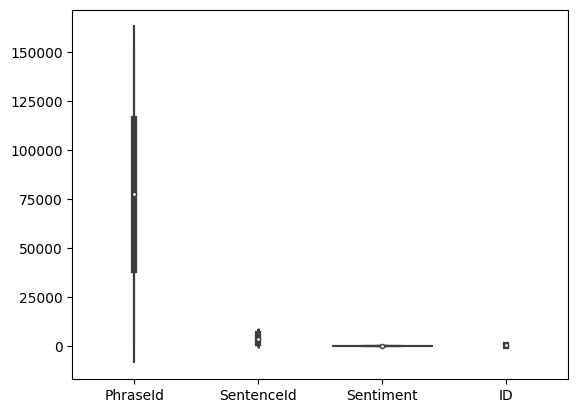

In [9]:
sns.violinplot(combined)

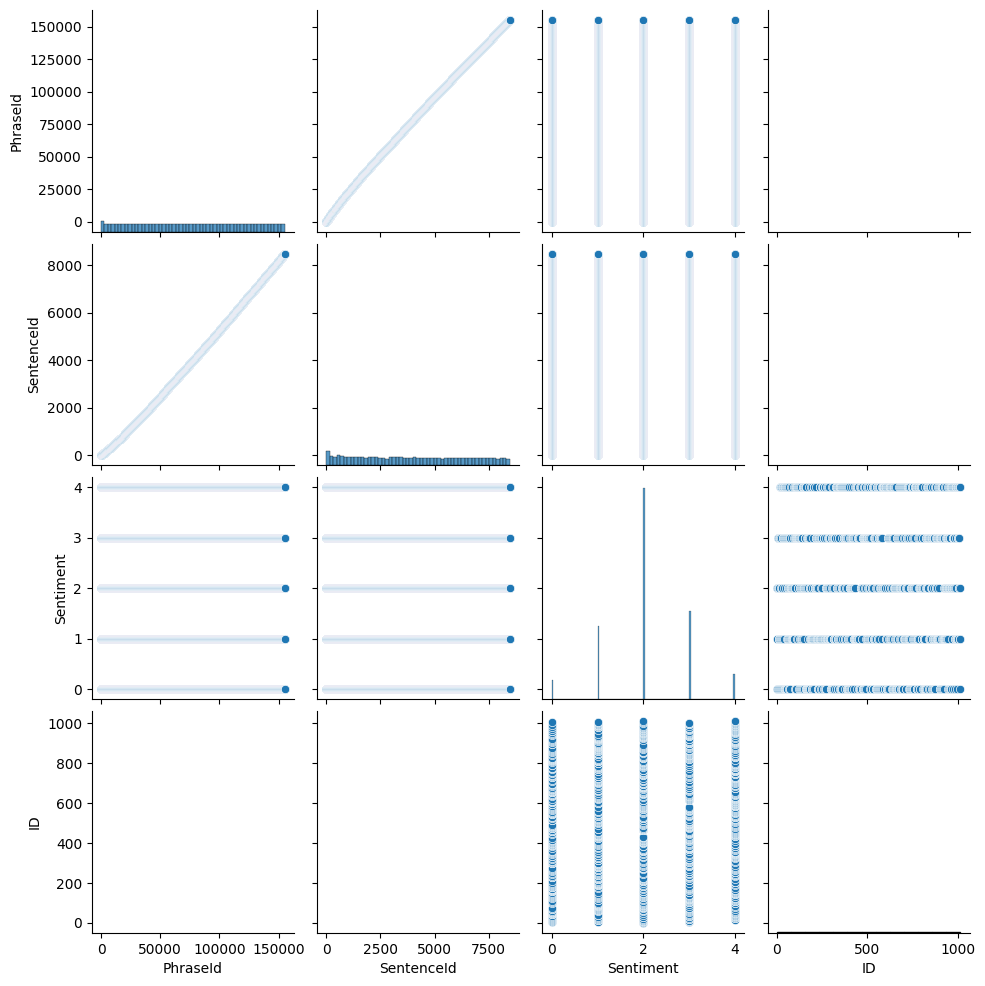

In [10]:
sns.pairplot(combined)

/tmp/ipykernel_35/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<AxesSubplot: >

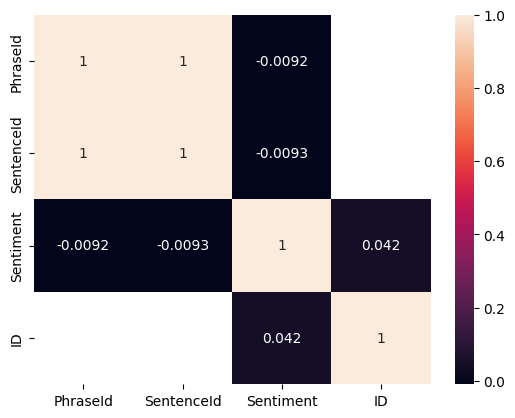

In [11]:
sns.heatmap(combined.corr(),annot=True)

<AxesSubplot: >

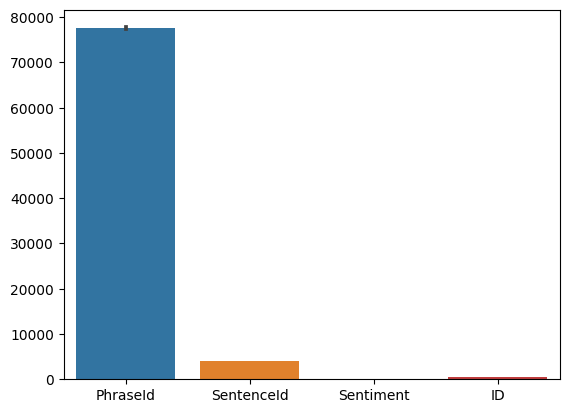

In [12]:
sns.barplot(combined)

<AxesSubplot: ylabel='Density'>

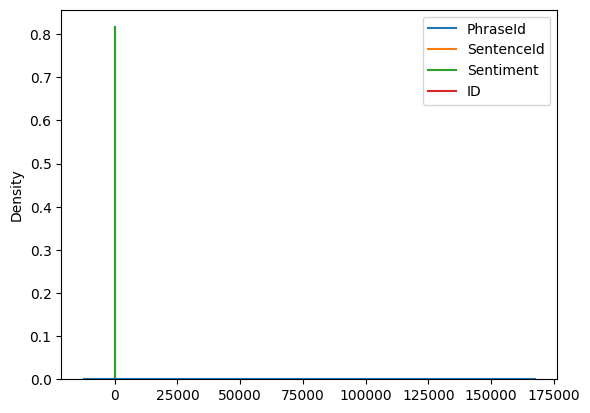

In [13]:
sns.kdeplot(combined)

<AxesSubplot: >

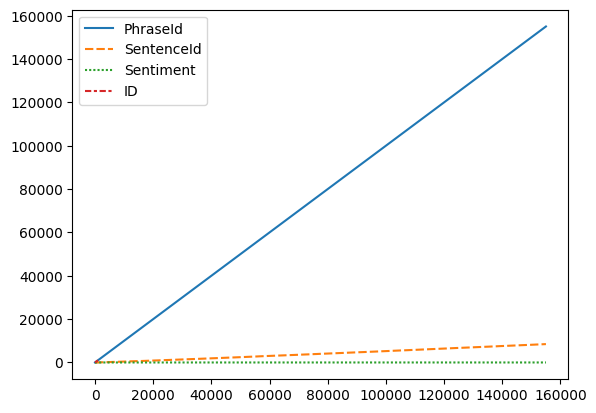

In [17]:
sns.lineplot(combined)

In [15]:
combined.skew()

/tmp/ipykernel_35/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


PhraseId      0.000000
SentenceId    0.073335
Sentiment    -0.010694
ID            0.000000
dtype: float64

In [16]:
combined.kurt()

/tmp/ipykernel_35/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


PhraseId     -1.200000
SentenceId   -1.216876
Sentiment     0.177241
ID           -1.200000
dtype: float64

In [18]:
combined['PhraseId']=combined['PhraseId'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_35/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


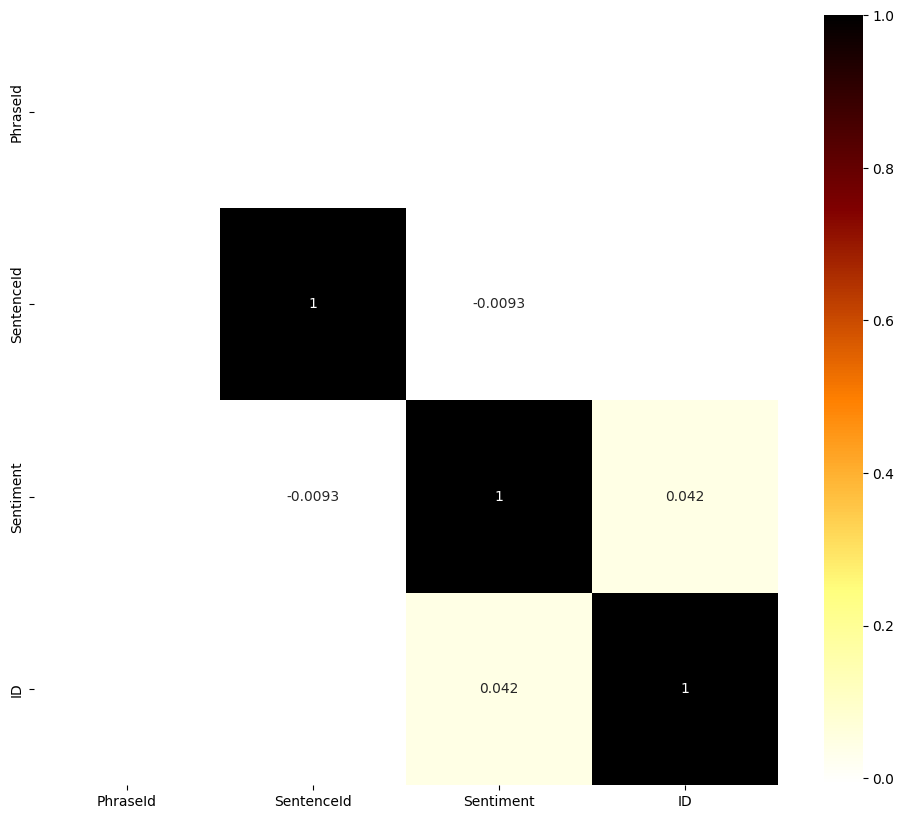

In [19]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

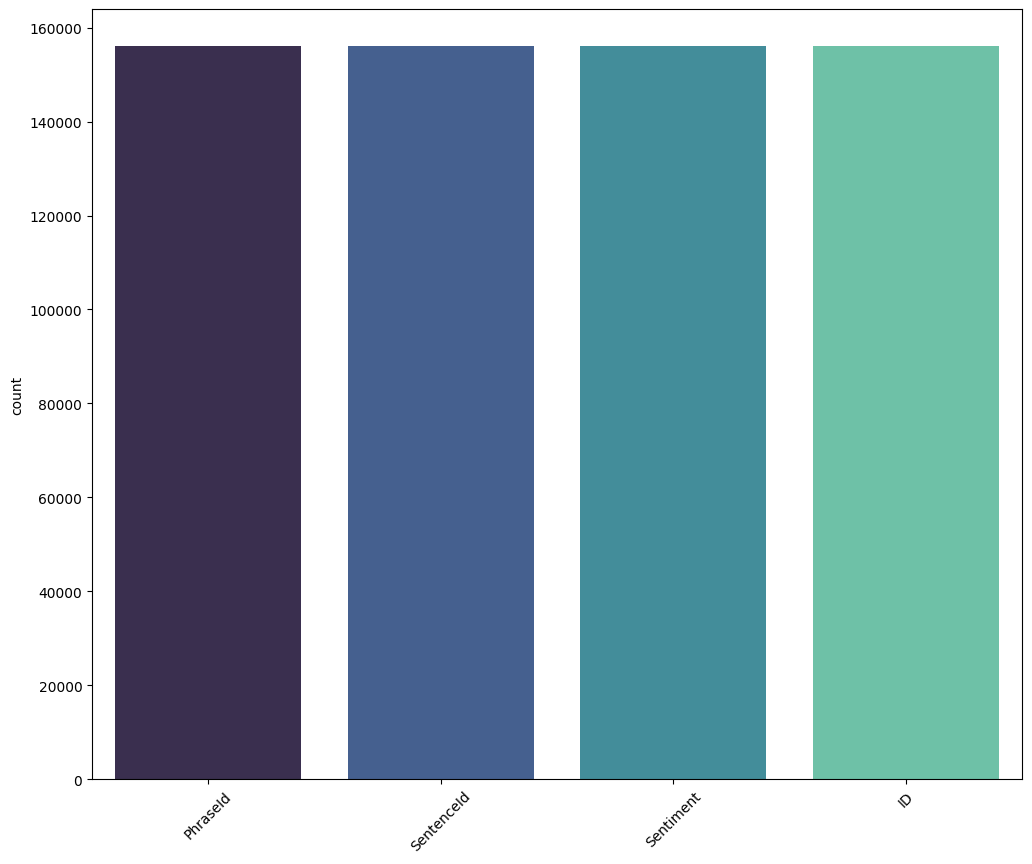

In [20]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

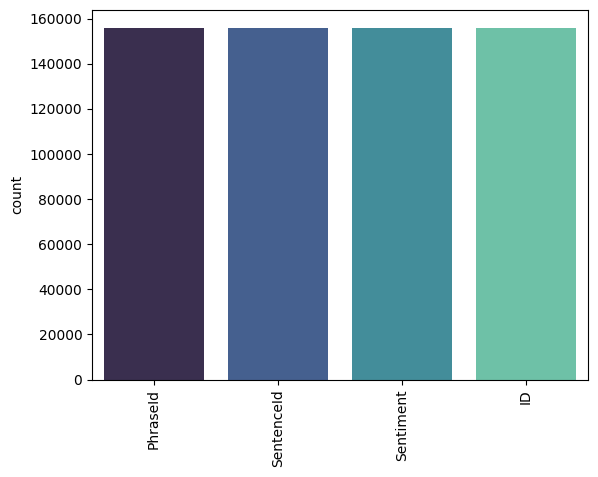

In [21]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3]),
 [Text(0, 0, 'PhraseId'),
  Text(1, 0, 'SentenceId'),
  Text(2, 0, 'Sentiment'),
  Text(3, 0, 'ID')])

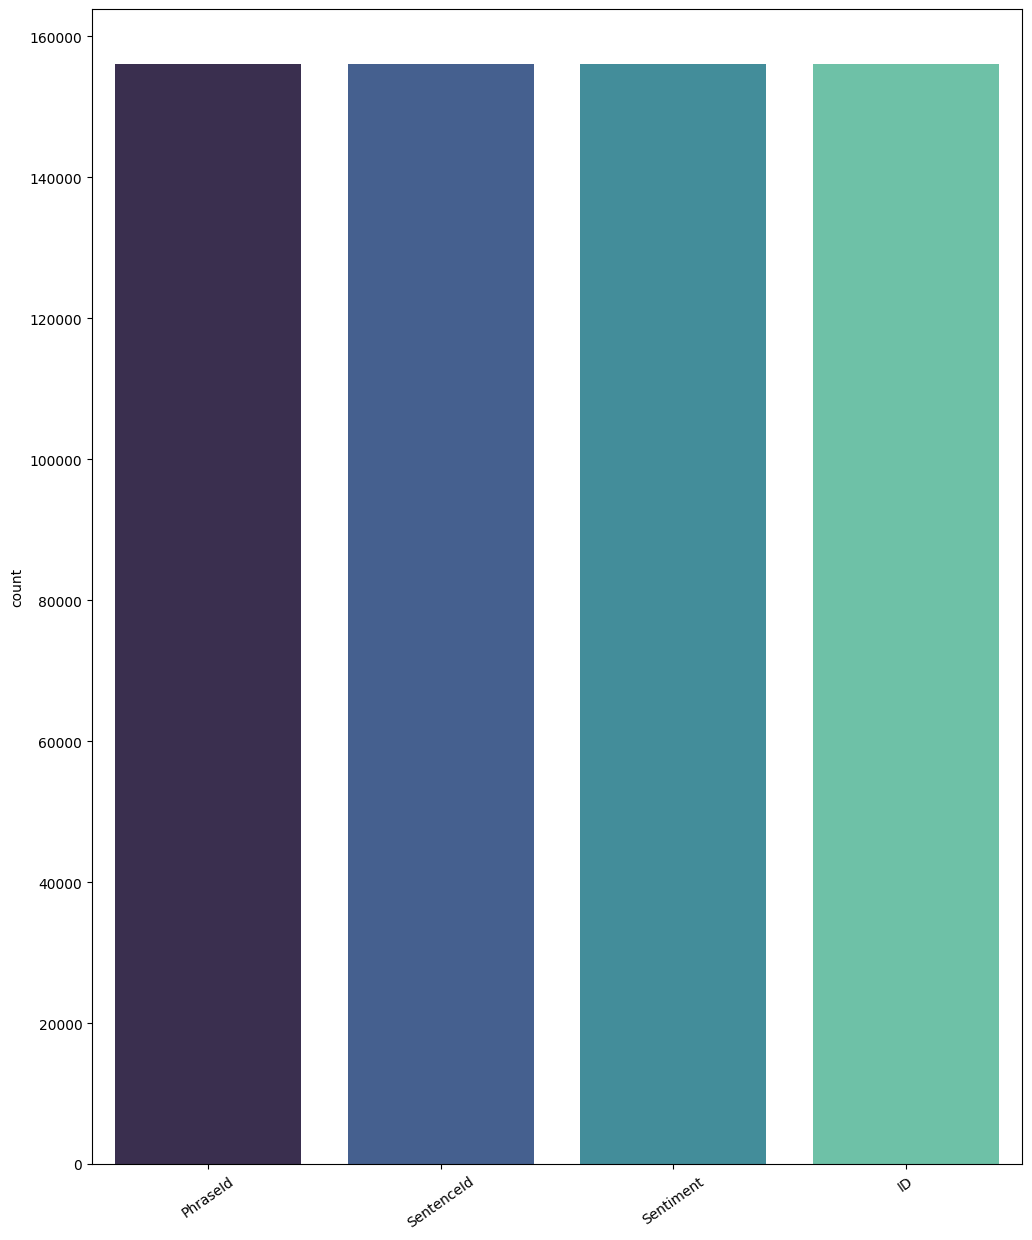

In [22]:
plt.figure(figsize=(12,15))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=35)

In [23]:
combined['PhraseId'].value_counts()

Series([], Name: PhraseId, dtype: int64)

In [24]:
combined['PhraseId'].unique()

array([nan])

In [28]:
cat_cols = combined.select_dtypes(include='object')

In [29]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

Phrase
A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .    1
the story of Matthew Shepard                                                                                                                                                                    1
film is yet to be made                                                                                                                                                                          1
is yet to be made                                                                                                                                                                               1
is yet                                                                                                                                                                                          1
                       

In [30]:
num_cols = combined.select_dtypes(include='number')

In [32]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

PhraseId
Series([], Name: PhraseId, dtype: int64)
__________________________________________________
SentenceId
1.0       63
5555.0    63
509.0     59
625.0     58
403.0     57
          ..
7572.0     1
6070.0     1
7906.0     1
7904.0     1
5518.0     1
Name: SentenceId, Length: 8471, dtype: int64
__________________________________________________
Sentiment
2    79259
3    32927
1    27298
4     9368
0     7208
Name: Sentiment, dtype: int64
__________________________________________________
ID
1.0       1
681.0     1
668.0     1
669.0     1
670.0     1
         ..
342.0     1
343.0     1
344.0     1
345.0     1
1012.0    1
Name: ID, Length: 1012, dtype: int64
__________________________________________________


In [ ]:
plt.figure(figsize=(5,5))
x=i
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

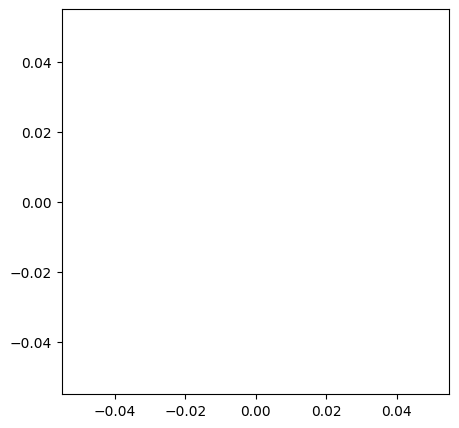

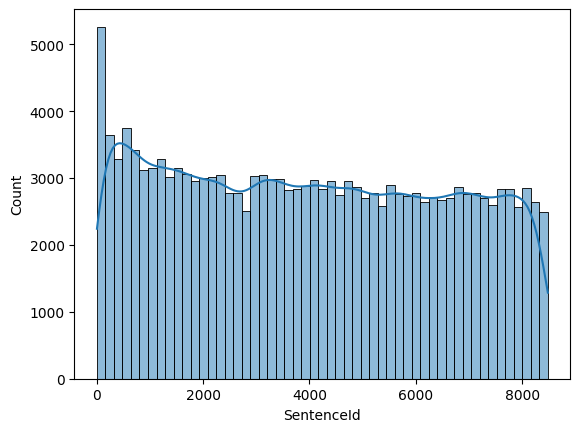

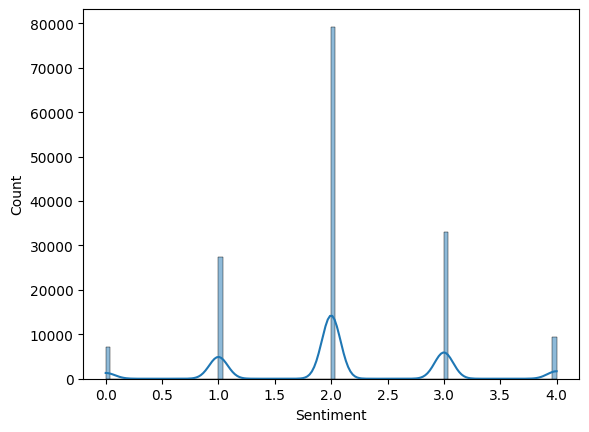

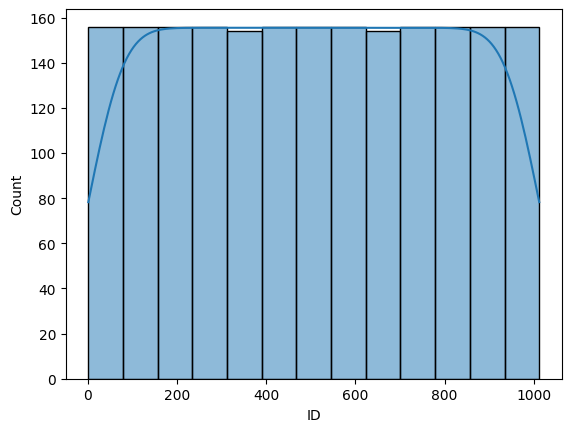

In [34]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()